#Import Required Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Load Dataset

In [3]:
df = pd.read_csv("../data/telecom_customer_churn.csv")

#Display First 5 Rows

In [4]:
df.head()

,Customer ID,Gender,Age,Married,Number of Dependents,City,Zip Code,Latitude,Longitude,Number of Referrals,...,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status,Target,Churn Category,Churn Reason
0,0002-ORFBO,Female,37,Yes,0,Frazier Park,93225,34.827662,-118.999073,2,...,65.6,593.30,0.00,0,381.51,974.81,Stayed,0,NaN,NaN
1,0003-MKNFE,Male,46,No,0,Glendale,91206,34.162515,-118.203869,0,...,-4.0,542.40,38.33,10,96.21,610.28,Stayed,0,NaN,NaN
2,0004-TLHLJ,Male,50,No,0,Costa Mesa,92627,33.645672,-117.922613,0,...,73.9,280.85,0.00,0,134.60,415.45,Churned,1,Competitor,Competitor had better devices
3,0011-IGKFF,Male,78,Yes,0,Martinez,94553,38.014457,-122.115432,1,...,98.0,1237.85,0.00,0,361.66,1599.51,Churned,1,Dissatisfaction,Product dissatisfaction
4,0013-EXCHZ,Female,75,Yes,0,Camarillo,93010,34.227846,-119.079903,3,...,83.9,267.40,0.00,0,22.14,289.54,Churned,1,Dissatisfaction,Network reliability


#Check Dataset Shape

In [5]:
df.shape

(7043, 39)

#Check Dataset Information

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 39 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   object 
 1   Gender                             7043 non-null   object 
 2   Age                                7043 non-null   int64  
 3   Married                            7043 non-null   object 
 4   Number of Dependents               7043 non-null   int64  
 5   City                               7043 non-null   object 
 6   Zip Code                           7043 non-null   int64  
 7   Latitude                           7043 non-null   float64
 8   Longitude                          7043 non-null   float64
 9   Number of Referrals                7043 non-null   int64  
 10  Tenure in Months                   7043 non-null   int64  
 11  Offer                              3166 non-null   objec

#Check Missing Values

In [7]:
df.isnull().sum()

Customer ID                             0
Gender                                  0
Age                                     0
Married                                 0
Number of Dependents                    0
City                                    0
Zip Code                                0
Latitude                                0
Longitude                               0
Number of Referrals                     0
Tenure in Months                        0
Offer                                3877
Phone Service                           0
Avg Monthly Long Distance Charges     682
Multiple Lines                        682
Internet Service                        0
Internet Type                        1526
Avg Monthly GB Download              1526
Online Security                      1526
Online Backup                        1526
Device Protection Plan               1526
Premium Tech Support                 1526
Streaming TV                         1526
Streaming Movies                  

#Handle Missing Values

In [8]:
df["Offer"] = df["Offer"].fillna("No Offer")
df["Avg Monthly Long Distance Charges"] = df["Avg Monthly Long Distance Charges"].fillna(0)
df["Multiple Lines"] = df["Multiple Lines"].fillna("No")
df["Internet Type"] = df["Internet Type"].fillna("No Internet")
df["Avg Monthly GB Download"] = df["Avg Monthly GB Download"].fillna(0)

internet_columns = [
    "Online Security",
    "Online Backup",
    "Device Protection Plan",
    "Premium Tech Support",
    "Streaming TV",
    "Streaming Movies",
    "Streaming Music"
]

for col in internet_columns:
    df[col] = df[col].fillna("No")

#Drop Leakage Columns

In [9]:
df.drop(columns=["Churn Category", "Churn Reason"], inplace=True)

#Verify

In [10]:
df.isnull().sum()

Customer ID                             0
Gender                                  0
Age                                     0
Married                                 0
Number of Dependents                    0
City                                    0
Zip Code                                0
Latitude                                0
Longitude                               0
Number of Referrals                     0
Tenure in Months                        0
Offer                                   0
Phone Service                           0
Avg Monthly Long Distance Charges       0
Multiple Lines                          0
Internet Service                        0
Internet Type                           0
Avg Monthly GB Download                 0
Online Security                         0
Online Backup                           0
Device Protection Plan                  0
Premium Tech Support                    0
Streaming TV                            0
Streaming Movies                  

#Check Duplicate Rows

In [11]:
df.duplicated().sum()

np.int64(0)

#Display Column Names

In [12]:
df.columns

Index(['Customer ID', 'Gender', 'Age', 'Married', 'Number of Dependents',
       'City', 'Zip Code', 'Latitude', 'Longitude', 'Number of Referrals',
       'Tenure in Months', 'Offer', 'Phone Service',
       'Avg Monthly Long Distance Charges', 'Multiple Lines',
       'Internet Service', 'Internet Type', 'Avg Monthly GB Download',
       'Online Security', 'Online Backup', 'Device Protection Plan',
       'Premium Tech Support', 'Streaming TV', 'Streaming Movies',
       'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charge', 'Total Charges', 'Total Refunds',
       'Total Extra Data Charges', 'Total Long Distance Charges',
       'Total Revenue', 'Customer Status', 'Target'],
      dtype='object')

#Drop Columns

In [13]:
drop_columns = [
    "Customer ID",
    "City",
    "Zip Code",
    "Latitude",
    "Longitude"
]

df = df.drop(columns=drop_columns)

#Check Target Variable Distribution

In [14]:
df["Target"].value_counts()

Target
0    5174
1    1869
Name: count, dtype: int64

#Drop Target Leakage Column

In [15]:
df = df.drop(columns=["Customer Status"])

#Import Required Libraries

In [16]:
import scorecardpy as sc

d:\anaconda3\envs\ds311\Lib\site-packages\scorecardpy\germancredit.py:5: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


#Calculate Weight of Evidence

In [ ]:
bins = sc.woebin(df, y="Target")

#Apply WOE Transformation

In [18]:
df_woe = sc.woebin_ply(df, bins)

[INFO] converting into woe values ...


#Display Information Values (IV) of Features

In [19]:
df_iv = sc.iv(df, y = "Target")
df_iv

,variable,info_value
11,Contract,1.493008
5,Number of Referrals,1.009157
26,Tenure in Months,0.919433
20,Monthly Charge,0.825033
6,Internet Type,0.566412
17,Number of Dependents,0.467914
15,Avg Monthly GB Download,0.450421
25,Offer,0.380451
18,Unlimited Data,0.375512
3,Internet Service,0.375183


#Drop Weak Features Based on IV

In [20]:
df_woe = df_woe.drop(columns=[
    "Gender_woe",
    "Phone Service_woe",
    "Multiple Lines_woe",
    "Streaming Music_woe",
    "Total Revenue_woe",
    "Streaming Movies_woe"
])

#Display Remaining WOE Features

In [21]:
df_woe.columns

Index(['Target', 'Total Refunds_woe', 'Total Extra Data Charges_woe',
       'Age_woe', 'Married_woe', 'Total Long Distance Charges_woe',
       'Contract_woe', 'Premium Tech Support_woe',
       'Avg Monthly Long Distance Charges_woe', 'Avg Monthly GB Download_woe',
       'Unlimited Data_woe', 'Total Charges_woe', 'Paperless Billing_woe',
       'Tenure in Months_woe', 'Number of Dependents_woe', 'Streaming TV_woe',
       'Online Backup_woe', 'Internet Service_woe',
       'Device Protection Plan_woe', 'Number of Referrals_woe',
       'Internet Type_woe', 'Payment Method_woe', 'Offer_woe',
       'Monthly Charge_woe', 'Online Security_woe'],
      dtype='object')

#Import library for VIF Calculation

In [22]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

#Select Independent Variables

In [23]:
X = df_woe.drop(columns = ["Target"])

#Calculate VIF For Each Feature

In [24]:
vif = pd.DataFrame()

vif['features'] = X.columns

vif["VIF"] = [
    variance_inflation_factor(X.values,i)
    for i in range (X.shape[1])
]

vif

,features,VIF
0,Total Refunds_woe,1.014382
1,Total Extra Data Charges_woe,15.755962
2,Age_woe,1.280892
3,Married_woe,1.600331
4,Total Long Distance Charges_woe,2.002568
5,Contract_woe,2.238735
6,Premium Tech Support_woe,1.473897
7,Avg Monthly Long Distance Charges_woe,1.084670
8,Avg Monthly GB Download_woe,22.320398
9,Unlimited Data_woe,27060.779494


#Drop Features with High VIF

In [25]:
df_woe = df_woe.drop(columns=[
    "Internet Service_woe",
    "Unlimited Data_woe",
    "Avg Monthly GB Download_woe",
    "Total Extra Data Charges_woe",
    "Internet Type_woe"
])

#Update Feature Matrix

In [26]:
X = df_woe.drop(columns = "Target")
y = df_woe["Target"]

#Split Data Into Training and Testing Sets

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.25,
    random_state=42,
    stratify=y
)

#Import Logistic Regression and GridSearchCV

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

#Create Logistic Regression Model

In [29]:
log_model = LogisticRegression(max_iter=1000)

#Define Hyperparameter Grid

In [30]:
param_grid = [
    {
        "penalty" : ['l1'],
        "C": [0.01, 0.1, 1, 10],
        "solver": ["liblinear"]
    },
    {
        "penalty" : ['l2'],
        "C": [0.01, 0.1, 1, 10],
        "solver": ["liblinear", "lbfgs"]
    }
]

#Perform Hyperparameter Tuning using GridSearchCV

In [31]:
grid_search = GridSearchCV(
    estimator=log_model,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

#Train Logistic Regression Model

In [32]:
grid_search.fit(X_train, y_train)

d:\anaconda3\envs\ds311\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\anaconda3\envs\ds311\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...max_iter=1000)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'C': [0.01, 0.1, ...], 'penalty': ['l1'], 'solver': ['liblinear']}, {'C': [0.01, 0.1, ...], 'penalty': ['l2'], 'solver': ['liblinear', 'lbfgs']}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callab

#Display Best Hyperparameters

In [33]:
print("Best Parameters :", grid_search.best_params_)
print("Best F1 Score :", grid_search.best_score_)

Best Parameters : {'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'}
Best F1 Score : 0.6923282714119973


#Predict Target Values on Test Data

In [34]:
y_pred = grid_search.predict(X_test)

#Import Model Evaluation Metrics

In [35]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

#Evaluate Logistic Regression Model

In [36]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision :", precision)
print("Recall :", recall)
print("F1 :", f1)

Accuracy : 0.8307779670641681
Precision : 0.6832971800433839
Recall : 0.6745182012847966
F1 : 0.6788793103448276


#Display Confusion Matrix

In [37]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[1148  146]
 [ 152  315]]


#Display Classification Report

In [38]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.89      0.89      1294
           1       0.68      0.67      0.68       467

    accuracy                           0.83      1761
   macro avg       0.78      0.78      0.78      1761
weighted avg       0.83      0.83      0.83      1761



#Import Decision Tree and GridSearchCV

In [39]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

#Create Decision Tree Classifier

In [40]:
dt_model = DecisionTreeClassifier(random_state=42)

#Define Hyperparameters for Decision Tree

In [41]:
param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 5, 7, 10],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

#Perform Hyperparameter Tuning using GridSearchCV

In [42]:
grid_search = GridSearchCV(
    estimator=dt_model,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

Train Decision Tree Mode

In [43]:
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"ve

#Display Best Hyperparameters

In [44]:
print("Best Parameters :", grid_search.best_params_)
print("Best F1 Score :", grid_search.best_score_)

Best Parameters : {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 10}
Best F1 Score : 0.6416643069062504


#Predict Target Values on Test Dataset

In [45]:
y_pred = grid_search.predict(X_test)

#Import Evaluation Metrics

In [46]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

#Evaluate Decision Tree Model

In [47]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision :", precision)
print("Recall :", recall)
print("F1 :", f1)

Accuracy : 0.8273708120386144
Precision : 0.6935866983372921
Recall : 0.6252676659528907
F1 : 0.6576576576576577


#Display Confusion Matrix

In [48]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[1165  129]
 [ 175  292]]


#Display Classification Report

In [49]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.90      0.88      1294
           1       0.69      0.63      0.66       467

    accuracy                           0.83      1761
   macro avg       0.78      0.76      0.77      1761
weighted avg       0.82      0.83      0.82      1761



#Feature Importance

In [50]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": grid_search.best_estimator_.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(10))

                                  Feature  Importance
4                            Contract_woe    0.368070
14                Number of Referrals_woe    0.146483
1                                 Age_woe    0.077223
10               Number of Dependents_woe    0.065908
17                     Monthly Charge_woe    0.062877
9                    Tenure in Months_woe    0.049713
6   Avg Monthly Long Distance Charges_woe    0.049416
15                     Payment Method_woe    0.034037
16                              Offer_woe    0.023300
5                Premium Tech Support_woe    0.018495


#Visualize Decision Tree

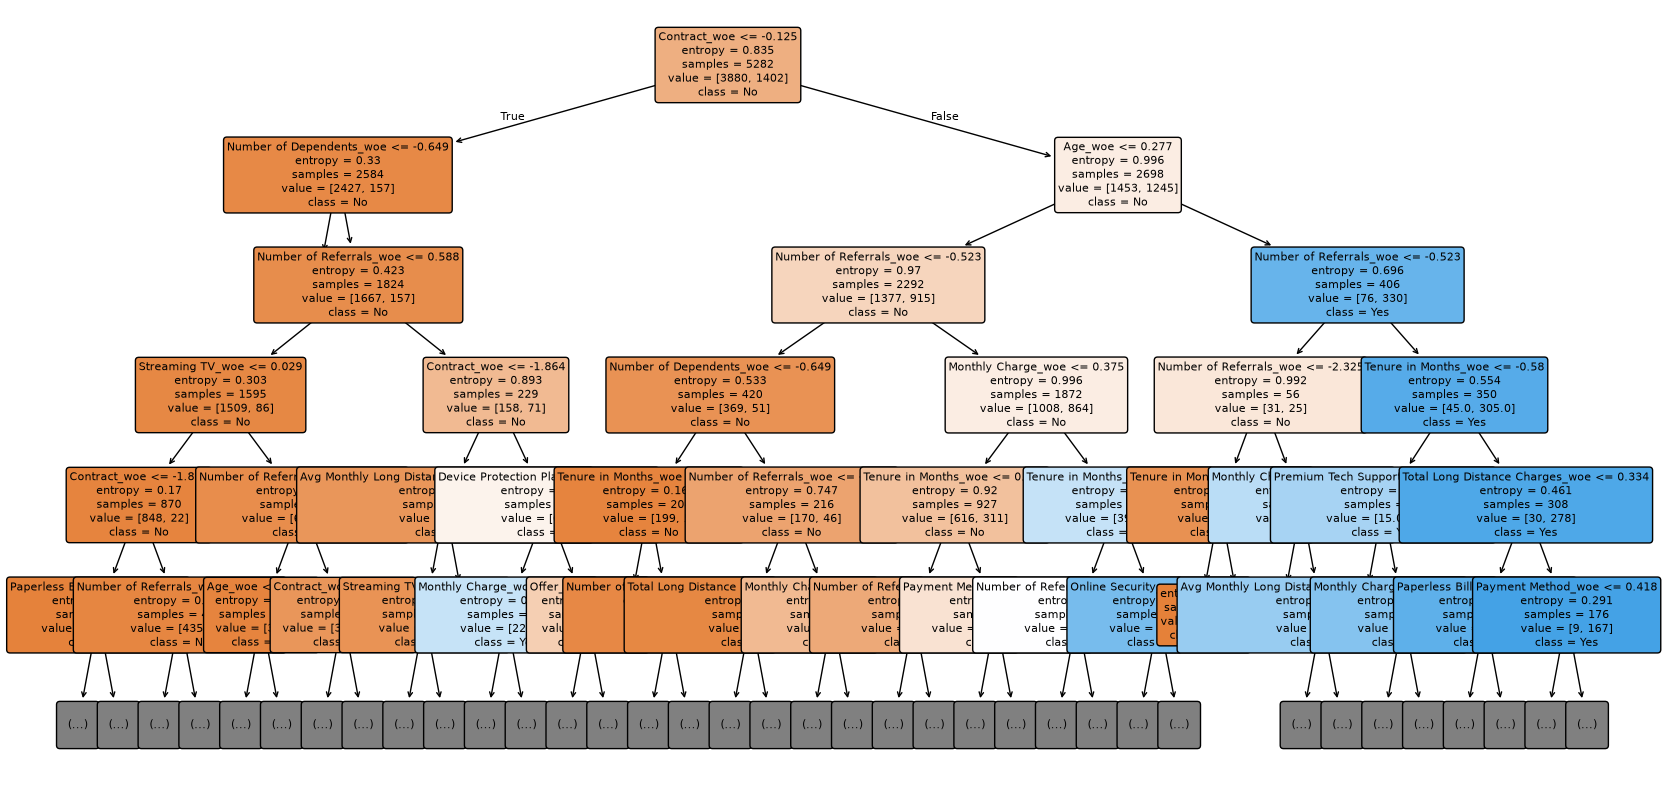

In [51]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))

plot_tree(
    grid_search.best_estimator_,
    feature_names=X.columns,
    class_names=["No", "Yes"],
    filled=True,
    rounded=True,
    max_depth=5,
    fontsize=8
)

plt.show()

#Import Random Forest and GridSearchCV

In [52]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

#Create Random Forest Model

In [53]:
rf_model = RandomForestClassifier(random_state=42)

#Define Hyperparameter Grid

In [54]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

#Perform Hyperparameter Tuning using GridSearchCV

In [55]:
grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=3,
    scoring="f1",
    n_jobs=-1
)

#Train Random Forest Model

In [56]:
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [10, 20], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"

#Display Best Hyperparameters

In [57]:
print("Best Parameters :", grid_search.best_params_)
print("Best F1 Score :", grid_search.best_score_)

Best Parameters : {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 200}
Best F1 Score : 0.6869091499569384


#Predict Target Values on Test Dataset

In [58]:
y_pred = grid_search.predict(X_test)

#Import Evaluation Metrics

In [59]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

#Evaluate Random Forest Model

In [60]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision :", precision)
print("Recall :", recall)
print("F1 :", f1)

Accuracy : 0.8392958546280522
Precision : 0.7233009708737864
Recall : 0.6381156316916489
F1 : 0.6780432309442548


#Display Confusion Matrix

In [61]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[1180  114]
 [ 169  298]]


#Display Classification Report

In [62]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.91      0.89      1294
           1       0.72      0.64      0.68       467

    accuracy                           0.84      1761
   macro avg       0.80      0.78      0.79      1761
weighted avg       0.83      0.84      0.84      1761



#Feature Importance

In [63]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": grid_search.best_estimator_.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
4,Contract_woe,0.235272
14,Number of Referrals_woe,0.135532
9,Tenure in Months_woe,0.108176
17,Monthly Charge_woe,0.107625
10,Number of Dependents_woe,0.057129
1,Age_woe,0.056540
15,Payment Method_woe,0.047300
7,Total Charges_woe,0.037582
3,Total Long Distance Charges_woe,0.032791
8,Paperless Billing_woe,0.029700


#Import AdaBoost and GridSearchCV

In [64]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import GridSearchCV

#Create AdaBoost Model

In [65]:
ada_model = AdaBoostClassifier(random_state=42)

#Define Hyperparameter Grid

In [66]:
param_grid = {
    "n_estimators": [50, 100],
    "learning_rate": [0.01, 0.1, 0.5, 1.0]
}

#Perform Hyperparameter Tuning using GridSearchCV

In [67]:
grid_search = GridSearchCV(
    estimator=ada_model,
    param_grid=param_grid,
    cv=3,
    scoring="f1",
    n_jobs=-1
)

#Train AdaBoost Model

In [88]:
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'colsample_bytree': [0.8, 1.0], 'learning_rate': [0.01, 0.1], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbos

#Display Best Hyperparameters

In [90]:
print("Best Parameters :", grid_search.best_params_)
print("Best F1 Score :", grid_search.best_score_)

Best Parameters : {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
Best F1 Score : 0.7050269741755961


#Predict Target Values on Test Dataset

In [91]:
y_pred = grid_search.predict(X_test)

#Import Evaluation Metrics

In [70]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

#Evaluate AdaBoost Model

In [92]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision :", precision)
print("Recall :", recall)
print("F1 :", f1)

Accuracy : 0.8461101646791596
Precision : 0.7168141592920354
Recall : 0.6937901498929336
F1 : 0.705114254624592


#Display Confusion Matrix

In [94]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[1166  128]
 [ 143  324]]


#Display Classification Report

In [95]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.90      0.90      1294
           1       0.72      0.69      0.71       467

    accuracy                           0.85      1761
   macro avg       0.80      0.80      0.80      1761
weighted avg       0.84      0.85      0.85      1761



#Feature Importance

In [96]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": grid_search.best_estimator_.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
4,Contract_woe,0.309645
10,Number of Dependents_woe,0.098110
14,Number of Referrals_woe,0.091423
9,Tenure in Months_woe,0.068854
1,Age_woe,0.066747
17,Monthly Charge_woe,0.056055
15,Payment Method_woe,0.048220
8,Paperless Billing_woe,0.046209
11,Streaming TV_woe,0.038443
18,Online Security_woe,0.028203


#Import XGBoost and GridSearchCV

In [79]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

#Create XGBoost Model

In [80]:
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

#Define Hyperparameter Grid

In [81]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

#Perform Hyperparameter Tuning

In [82]:
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

#Train XGBoost Model

In [83]:
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'colsample_bytree': [0.8, 1.0], 'learning_rate': [0.01, 0.1], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbos

#Display Best Parameters

In [84]:
print("Best Parameters :", grid_search.best_params_)
print("Best F1 Score :", grid_search.best_score_)

Best Parameters : {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
Best F1 Score : 0.7050269741755961


#Predict on Test Data

In [85]:
y_pred = grid_search.predict(X_test)

#Evaluate XGBoost Model

In [97]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision :", precision)
print("Recall :", recall)
print("F1 :", f1)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy : 0.8461101646791596
Precision : 0.7168141592920354
Recall : 0.6937901498929336
F1 : 0.705114254624592
[[1166  128]
 [ 143  324]]
              precision    recall  f1-score   support

           0       0.89      0.90      0.90      1294
           1       0.72      0.69      0.71       467

    accuracy                           0.85      1761
   macro avg       0.80      0.80      0.80      1761
weighted avg       0.84      0.85      0.85      1761



#Feature Importance

In [98]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": grid_search.best_estimator_.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
4,Contract_woe,0.309645
10,Number of Dependents_woe,0.098110
14,Number of Referrals_woe,0.091423
9,Tenure in Months_woe,0.068854
1,Age_woe,0.066747
17,Monthly Charge_woe,0.056055
15,Payment Method_woe,0.048220
8,Paperless Billing_woe,0.046209
11,Streaming TV_woe,0.038443
18,Online Security_woe,0.028203


## Final Project Conclusion

Five machine learning models—Logistic Regression, Decision Tree, Random Forest, AdaBoost, and XGBoost—were developed and evaluated for predicting telecom customer churn. The models were compared using Accuracy, Precision, Recall, and F1-score. Since the primary objective was to identify customers who were likely to churn, Recall and F1-score were considered the most important evaluation metrics. XGBoost and AdaBoost achieved the highest Accuracy (84.61%), Recall (69.38%), and F1-score (70.51%), demonstrating the best overall predictive performance. Random Forest achieved the highest Precision (72.33%), making its positive churn predictions the most reliable, while Logistic Regression provided competitive performance with the advantage of interpretability. Decision Tree showed the weakest overall performance. Based on the evaluation metrics and the business objective, XGBoost was selected as the final model because gradient boosting generally offers better generalization, handles complex feature interactions effectively, and is widely used for structured classification problems.